In [1]:
# Cell 1: Imports
import os
import ast
import numpy as np
import pandas as pd
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from shapely import wkt
from tqdm import tqdm
import matplotlib.pyplot as plt

# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [2]:
# Cell 2: Config
class Config:
    CSV_PATH = '/kaggle/input/datasets/sandhiwangiyana/spacenet-6-multisensor-allweather-mapping/AOI_11_Rotterdam/SummaryData/SN6_Train_AOI_11_Rotterdam_Buildings.csv' # Replace with your CSV path
    OPTICAL_DIR = '/kaggle/input/datasets/sandhiwangiyana/spacenet-6-multisensor-allweather-mapping/AOI_11_Rotterdam/PS-RGB' # Replace with Optical dir
    SAR_DIR = '/kaggle/input/datasets/sandhiwangiyana/spacenet-6-multisensor-allweather-mapping/AOI_11_Rotterdam/SAR-Intensity'         # Replace with SAR dir
    
    IMG_SIZE = 512 # As per SpaceNet 6 standards mentioned in the paper
    BATCH_SIZE = 8
    EPOCHS = 50
    LR = 1e-4
    NUM_SAMPLES = 3000 # Limit for quick training/testing
    
    # Loss weights as defined in the paper
    LAMBDA_FOOTPRINT = 1.0
    LAMBDA_HEIGHT = 0.5

In [3]:
# Cell 3: Dataset Class (With alignment fix)
import tifffile as tiff

class SpaceNetDataset(Dataset):
    def __init__(self, csv_path, optical_dir, sar_dir, img_size=512, limit=None):
        self.optical_dir = optical_dir
        self.sar_dir = sar_dir
        self.img_size = img_size
        
        df = pd.read_csv(csv_path)
        self.grouped = df.groupby('ImageId')
        self.image_ids = list(self.grouped.groups.keys())
        
        if limit:
            self.image_ids = self.image_ids[:limit]
            
        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Resize((img_size, img_size), antialias=True)
        ])

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        img_id = self.image_ids[idx]
        group = self.grouped.get_group(img_id)
        
        opt_path = os.path.join(self.optical_dir, f"SN6_Train_AOI_11_Rotterdam_PS-RGB_{img_id}.tif") 
        sar_path = os.path.join(self.sar_dir, f"SN6_Train_AOI_11_Rotterdam_SAR-Intensity_{img_id}.tif")

        # 1. Read Images
        if not os.path.exists(opt_path) or not os.path.exists(sar_path):
            opt_img = np.zeros((self.img_size, self.img_size, 3), dtype=np.uint8)
            sar_img = np.zeros((self.img_size, self.img_size, 3), dtype=np.uint8)
            native_h, native_w = self.img_size, self.img_size
        else:
            try:
                opt_img = tiff.imread(opt_path)
                sar_img = tiff.imread(sar_path)
                
                # --- NEW: Ensure (H, W, C) Format ---
                if len(opt_img.shape) == 3 and opt_img.shape[0] in [3, 4]: 
                    opt_img = np.transpose(opt_img, (1, 2, 0)) # Convert C,H,W to H,W,C
                if len(sar_img.shape) == 3 and sar_img.shape[0] in [3, 4]:
                    sar_img = np.transpose(sar_img, (1, 2, 0))
                
                native_h, native_w = opt_img.shape[0], opt_img.shape[1]
                
                # Slicing is now perfectly safe
                if len(opt_img.shape) == 3 and opt_img.shape[2] >= 3:
                    opt_img = opt_img[:, :, :3]
                if opt_img.dtype != np.uint8:
                    opt_max = np.max(opt_img) if np.max(opt_img) > 0 else 1.0
                    opt_img = (np.clip(opt_img / opt_max, 0, 1) * 255).astype(np.uint8)
                    
                if len(sar_img.shape) == 3 and sar_img.shape[2] >= 3:
                    sar_img = sar_img[:, :, :3]
                elif len(sar_img.shape) == 2:
                    sar_img = np.stack((sar_img,)*3, axis=-1)
                    
                if sar_img.dtype != np.uint8:
                    sar_max = np.max(sar_img) if np.max(sar_img) > 0 else 1.0
                    sar_img = (np.clip(sar_img / sar_max, 0, 1) * 255).astype(np.uint8)
            except Exception as e:
                opt_img = np.zeros((self.img_size, self.img_size, 3), dtype=np.uint8)
                sar_img = np.zeros((self.img_size, self.img_size, 3), dtype=np.uint8)
                native_h, native_w = self.img_size, self.img_size
                
        # 2. Draw Ground Truth Masks at NATIVE resolution (900x900)
        mask_footprint = np.zeros((native_h, native_w), dtype=np.float32)
        mask_height = np.zeros((native_h, native_w), dtype=np.float32)
        
        for _, row in group.iterrows():
            poly_wkt = row['PolygonWKT_Pix']
            height = row['Mean_Building_Height']
            
            if pd.isna(poly_wkt) or poly_wkt.strip() == 'POLYGON EMPTY':
                continue
                
            height = 0.0 if pd.isna(height) else max(0.0, float(height))
                
            try:
                poly = wkt.loads(poly_wkt)
                coords = np.array(poly.exterior.coords, dtype=np.int32)
                cv2.fillPoly(mask_footprint, [coords], 1.0)
                cv2.fillPoly(mask_height, [coords], height)
            except Exception as e:
                pass
                
        # --- THE FIX: Resize masks to 512x512 so they align with the image! ---
        if native_h != self.img_size or native_w != self.img_size:
            mask_footprint = cv2.resize(mask_footprint, (self.img_size, self.img_size), interpolation=cv2.INTER_NEAREST)
            mask_height = cv2.resize(mask_height, (self.img_size, self.img_size), interpolation=cv2.INTER_NEAREST)
                
        # 3. Convert to Tensors
        opt_tensor = self.transform(opt_img)
        sar_tensor = self.transform(sar_img)
        
        mask_footprint = torch.tensor(mask_footprint, dtype=torch.long)
        mask_height = torch.tensor(mask_height, dtype=torch.float32).unsqueeze(0)
        
        mask_height = torch.nan_to_num(mask_height, nan=0.0)
        
        return opt_tensor, sar_tensor, mask_footprint, mask_height, img_id

In [4]:
# Cell 4: Modules (Encoders & Fusion)
class PretrainedCNNEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        resnet = models.resnet34(weights=models.ResNet34_Weights.IMAGENET1K_V1)
        self.initial = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu, resnet.maxpool) # F0
        self.layer1 = resnet.layer1 # F1
        self.layer2 = resnet.layer2 # F2
        self.layer3 = resnet.layer3 # F3
        self.layer4 = resnet.layer4 # Fout (1/32 resolution, we will upsample to 1/16 to match paper)
        
        # The paper uses 1/16 as the lowest resolution. We'll adjust layer4 output.
        self.up_align = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)

    def forward(self, x):
        f0 = self.initial(x)  # H/4 (ResNet skips H/2 due to initial conv stride + maxpool)
        f1 = self.layer1(f0)  # H/4
        f2 = self.layer2(f1)  # H/8
        f3 = self.layer3(f2)  # H/16
        f4 = self.layer4(f3)  # H/32
        f_out = self.up_align(f4) # H/16, Channels: 256
        return f0, f1, f2, f_out

class CrossFusionBlock(nn.Module):
    def __init__(self, embed_dim=256, num_heads=4):
        super().__init__()
        self.norm1_sar = nn.LayerNorm(embed_dim)
        self.norm1_opt = nn.LayerNorm(embed_dim)
        
        self.cross_attn_sar = nn.MultiheadAttention(embed_dim, num_heads, batch_first=True)
        self.cross_attn_opt = nn.MultiheadAttention(embed_dim, num_heads, batch_first=True)
        
        self.norm2_sar = nn.LayerNorm(embed_dim)
        self.norm2_opt = nn.LayerNorm(embed_dim)
        
        self.mlp_sar = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * 2), nn.GELU(), nn.Linear(embed_dim * 2, embed_dim)
        )
        self.mlp_opt = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * 2), nn.GELU(), nn.Linear(embed_dim * 2, embed_dim)
        )

    def forward(self, sar_feat, opt_feat):
        # Reshape (B, C, H, W) -> (B, H*W, C)
        B, C, H, W = sar_feat.shape
        sar_flat = sar_feat.flatten(2).transpose(1, 2)
        opt_flat = opt_feat.flatten(2).transpose(1, 2)
        
        # Norm
        sar_norm = self.norm1_sar(sar_flat)
        opt_norm = self.norm1_opt(opt_flat)
        
        # Cross Attention: Modality acts as Query, the OTHER modality acts as Key/Value
        attn_sar, _ = self.cross_attn_sar(sar_norm, opt_norm, opt_norm)
        sar_out = sar_flat + attn_sar
        
        attn_opt, _ = self.cross_attn_opt(opt_norm, sar_norm, sar_norm)
        opt_out = opt_flat + attn_opt
        
        # MLP
        sar_out = sar_out + self.mlp_sar(self.norm2_sar(sar_out))
        opt_out = opt_out + self.mlp_opt(self.norm2_opt(opt_out))
        
        # Reshape back to (B, C, H, W)
        sar_out = sar_out.transpose(1, 2).view(B, C, H, W)
        opt_out = opt_out.transpose(1, 2).view(B, C, H, W)
        
        return sar_out, opt_out

In [5]:
# Cell 5: Decoder and Full Architecture
class DecoderBlock(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()
        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels + skip_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x, skip):
        x = self.up(x)
        # Ensure spatial dimensions match if rounding issues occur
        if x.shape[2:] != skip.shape[2:]:
            x = F.interpolate(x, size=skip.shape[2:])
        x = torch.cat([x, skip], dim=1)
        return self.conv(x)

class FusionHeightNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc_opt = PretrainedCNNEncoder()
        self.enc_sar = PretrainedCNNEncoder()
        
        self.cross_fusion = CrossFusionBlock(embed_dim=256)
        
        # Joint fusion of optical and SAR for the shared lowest resolution
        self.fusion_conv = nn.Conv2d(512, 256, 1) 
        
        # Footprint Decoder (using optical skips for sharp edges)
        self.foot_dec1 = DecoderBlock(256, 128, 128) # Uses f2
        self.foot_dec2 = DecoderBlock(128, 64, 64)   # Uses f1
        self.foot_dec3 = DecoderBlock(64, 64, 64)    # Uses f0
        self.foot_head = nn.Sequential(
            nn.Conv2d(64, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Upsample(scale_factor=4, mode='bilinear'), # Upscale remaining H/4 to H
            nn.Conv2d(32, 2, 1) # 2 Classes: Background, Footprint
        )
        
        # Height Decoder (using SAR skips for structural geometry)
        self.height_dec1 = DecoderBlock(256, 128, 128)
        self.height_dec2 = DecoderBlock(128, 64, 64)
        self.height_dec3 = DecoderBlock(64, 64, 64)
        self.height_head = nn.Sequential(
            nn.Conv2d(64, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Upsample(scale_factor=4, mode='bilinear'),
            nn.Conv2d(32, 1, 1),
            nn.Sigmoid() # Restricts output to 0-1 (Assumes GT height is normalized!)
        )

    def forward(self, opt, sar):
        o_f0, o_f1, o_f2, o_fout = self.enc_opt(opt)
        s_f0, s_f1, s_f2, s_fout = self.enc_sar(sar)
        
        # Multi-Level Cross Fusion at the bottleneck
        s_fused, o_fused = self.cross_fusion(s_fout, o_fout)
        
        # Combine for decoder input
        f_fusion = self.fusion_conv(torch.cat([o_fused, s_fused], dim=1))
        
        # Footprint Branch
        d_foot = self.foot_dec1(f_fusion, o_f2)
        d_foot = self.foot_dec2(d_foot, o_f1)
        d_foot = self.foot_dec3(d_foot, o_f0)
        pred_footprint = self.foot_head(d_foot)
        
        # Height Branch
        d_height = self.height_dec1(f_fusion, s_f2)
        d_height = self.height_dec2(d_height, s_f1)
        d_height = self.height_dec3(d_height, s_f0)
        base_height = self.height_head(d_height)
        
        # Semantic Refinement (Paper Eq 16)
        # Instead of non-differentiable argmax, we use the probability of the footprint class
        footprint_prob = F.softmax(pred_footprint, dim=1)[:, 1:2, :, :] 
        pred_height = base_height * footprint_prob
        
        return pred_footprint, pred_height

In [6]:
# Cell 6: Losses
def dice_loss(pred, target, smooth=1e-6):
    pred = F.softmax(pred, dim=1)[:, 1, :, :] # Take footprint class prob
    intersection = (pred * target).sum(dim=(1, 2))
    union = pred.sum(dim=(1, 2)) + target.sum(dim=(1, 2))
    dice = (2. * intersection + smooth) / (union + smooth)
    return 1 - dice.mean()

def fusion_loss(pred_foot, pred_height, gt_foot, gt_height, config):
    # Footprint Loss (CrossEntropy + Dice)
    ce_loss = F.cross_entropy(pred_foot, gt_foot)
    d_loss = dice_loss(pred_foot, gt_foot)
    L_footprint = ce_loss + d_loss
    
    # Height Loss (Smooth L1)
    # Note: Ensure your gt_height is normalized between 0-1 for this to work correctly with Sigmoid
    # E.g., gt_height = gt_height / MAX_HEIGHT
    L_height = F.smooth_l1_loss(pred_height, gt_height)
    
    # Total
    L_total = (config.LAMBDA_FOOTPRINT * L_footprint) + (config.LAMBDA_HEIGHT * L_height)
    return L_total, L_footprint, L_height

In [7]:
# MODIFIED Cell 7: Professional Training Loop with Validation
from torch.utils.data import random_split

if __name__ == '__main__':
    full_dataset = SpaceNetDataset(
        csv_path=Config.CSV_PATH, 
        optical_dir=Config.OPTICAL_DIR, 
        sar_dir=Config.SAR_DIR, 
        img_size=Config.IMG_SIZE,
        limit=Config.NUM_SAMPLES 
    )
    
    train_size = int(0.8 * len(full_dataset))
    val_size = len(full_dataset) - train_size
    train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])
    
    # Inside Cell 7
    train_loader = DataLoader(train_dataset, batch_size=Config.BATCH_SIZE * 2, shuffle=True, num_workers=4, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=Config.BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
    
    model = FusionHeightNet().to(device)
    if torch.cuda.device_count() > 1:
        print(f"🚀 Using {torch.cuda.device_count()} GPUs for training!")
        model = nn.DataParallel(model)

    optimizer = torch.optim.AdamW(model.parameters(), lr=Config.LR, weight_decay=1e-4)
    # The scheduler now monitors Validation Loss
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.1)
    
    MAX_HEIGHT = 100.0 
    best_val_loss = float('inf') 

    print(f"Starting Training: {train_size} Train | {val_size} Val")
    for epoch in range(Config.EPOCHS):
        
        # --- 1. TRAINING PHASE ---
        model.train()
        train_loss = 0.0
        progress = tqdm(train_loader, desc=f"Epoch {epoch+1}/{Config.EPOCHS} [Train]")
        
        for opt, sar, gt_foot, gt_height, _ in progress:
            opt, sar = opt.to(device), sar.to(device)
            gt_foot, gt_height = gt_foot.to(device), gt_height.to(device)
            gt_height = (torch.log1p(gt_height) / np.log1p(MAX_HEIGHT)).to(device)
            
            if torch.isnan(gt_height).any() or torch.isnan(opt).any() or torch.isnan(sar).any(): continue 
            
            optimizer.zero_grad()
            pred_foot, pred_height = model(opt, sar)
            
            loss, _, _ = fusion_loss(pred_foot, pred_height, gt_foot, gt_height, Config)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            train_loss += loss.item()
            progress.set_postfix({'Train Loss': loss.item()})
            
        avg_train_loss = train_loss / len(train_loader)
        
        # --- 2. VALIDATION PHASE ---
        model.eval()
        val_loss = 0.0
        with torch.no_grad(): # Critical: No gradients during validation
            for opt, sar, gt_foot, gt_height, _ in val_loader:
                opt, sar = opt.to(device), sar.to(device)
                gt_foot, gt_height = gt_foot.to(device), gt_height.to(device)
                gt_height = (torch.log1p(gt_height) / np.log1p(MAX_HEIGHT)).to(device)
                
                if torch.isnan(gt_height).any() or torch.isnan(opt).any() or torch.isnan(sar).any(): continue 
                
                pred_foot, pred_height = model(opt, sar)
                loss, _, _ = fusion_loss(pred_foot, pred_height, gt_foot, gt_height, Config)
                val_loss += loss.item()
                
        avg_val_loss = val_loss / len(val_loader)
        print(f"Epoch {epoch+1} Summary | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
        
        # --- 3. SCHEDULER & SAVING ---
        scheduler.step(avg_val_loss) # Step based on Validation!
        is_parallel = isinstance(model, nn.DataParallel)
        
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            state_dict = model.module.state_dict() if is_parallel else model.state_dict()
            torch.save(state_dict, 'fusion_height_net_best.pth')
            print(f"🏆 Best model saved! (Val Loss: {best_val_loss:.4f})")
        
        latest_dict = model.module.state_dict() if is_parallel else model.state_dict()
        torch.save(latest_dict, 'fusion_height_net_latest.pth')

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 190MB/s]


🚀 Using 2 GPUs for training!
Starting Training: 2400 Train | 600 Val


Epoch 1/50 [Train]: 100%|██████████| 150/150 [03:09<00:00,  1.27s/it, Train Loss=0.907]


Epoch 1 Summary | Train Loss: 1.1185 | Val Loss: 0.9776
🏆 Best model saved! (Val Loss: 0.9776)


...

Epoch 48 Summary | Train Loss: 0.1545 | Val Loss: 0.2180


Epoch 49/50 [Train]: 100%|██████████| 150/150 [02:59<00:00,  1.20s/it, Train Loss=0.135] 


Epoch 49 Summary | Train Loss: 0.1534 | Val Loss: 0.2184


Epoch 50/50 [Train]: 100%|██████████| 150/150 [02:58<00:00,  1.19s/it, Train Loss=0.19]  


Epoch 50 Summary | Train Loss: 0.1529 | Val Loss: 0.2172
🏆 Best model saved! (Val Loss: 0.2172)


In [8]:
# Cell 7.6: Package Validation TIFFs for Local Demo
import os
import shutil
from IPython.display import FileLink

def export_val_images_for_demo(val_dataset, opt_dir, sar_dir, out_zip_name="val_images_demo", limit=50):
    temp_dir = "/kaggle/working/val_demo_staging"
    
    # Clean up old staging area if it exists
    if os.path.exists(temp_dir):
        shutil.rmtree(temp_dir)
    os.makedirs(temp_dir, exist_ok=True)

    print(f"Copying raw TIFFs for up to {limit if limit else 'ALL'} validation images...")
    
    count = 0
    for i in range(len(val_dataset)):
        if limit is not None and count >= limit:
            break
            
        # Extract the Image ID from the dataset tuple
        _, _, _, _, img_id = val_dataset[i]

        # Construct the exact file paths based on SpaceNet 6 naming conventions
        opt_src = os.path.join(opt_dir, f"SN6_Train_AOI_11_Rotterdam_PS-RGB_{img_id}.tif")
        sar_src = os.path.join(sar_dir, f"SN6_Train_AOI_11_Rotterdam_SAR-Intensity_{img_id}.tif")

        # Copy them to the staging folder if they exist
        if os.path.exists(opt_src) and os.path.exists(sar_src):
            shutil.copy(opt_src, os.path.join(temp_dir, f"OPT_{img_id}.tif"))
            shutil.copy(sar_src, os.path.join(temp_dir, f"SAR_{img_id}.tif"))
            count += 1

    print(f"Zipping {count * 2} files into {out_zip_name}.zip... (This might take a minute)")
    
    # Zip the directory
    shutil.make_archive(f"/kaggle/working/{out_zip_name}", 'zip', temp_dir)

    # Delete the unzipped folder to save Kaggle disk space
    shutil.rmtree(temp_dir)

    print("✅ Zip file created successfully!")
    return FileLink(f"{out_zip_name}.zip")

# Execute the packaging script (uses your existing Config and val_dataset)
if __name__ == '__main__':
    # Change limit=None if you want all 500+ pairs (Warning: Huge file size!)
    download_link = export_val_images_for_demo(
        val_dataset, 
        Config.OPTICAL_DIR, 
        Config.SAR_DIR, 
        limit=50 
    )
    display(download_link)

Copying raw TIFFs for up to 50 validation images...
Zipping 100 files into val_images_demo.zip... (This might take a minute)
✅ Zip file created successfully!


/kaggle/working/val_images_demo.zip

In [9]:
# MODIFIED Cell 8: Percentage-Based Metrics Logic
import scipy.ndimage as ndimage
import numpy as np

def calculate_instance_metrics(pred_foot_prob, pred_height_map, gt_foot, gt_height_map, height_tolerance_pct=0.25):
    """
    Calculates building counts and height accuracy within a PERCENTAGE tolerance.
    """
    # 1. Binarize the predicted footprint (Threshold at 0.5)
    pred_mask = (pred_foot_prob > 0.5).astype(np.uint8)
    gt_mask = gt_foot.astype(np.uint8)
    
    # 2. Extract distinct building instances using connected components
    pred_labeled, pred_num_features = ndimage.label(pred_mask)
    gt_labeled, gt_num_features = ndimage.label(gt_mask)
    
    matched_buildings = 0
    height_within_tolerance_count = 0
    
    # 3. Match predicted buildings to GT buildings
    for i in range(1, pred_num_features + 1):
        # Get pixels for this specific predicted building
        pred_building_pixels = (pred_labeled == i)
        
        # Find which GT building overlaps the most with this prediction
        overlapping_gt_labels = gt_labeled[pred_building_pixels]
        overlapping_gt_labels = overlapping_gt_labels[overlapping_gt_labels > 0]
        
        if len(overlapping_gt_labels) > 0:
            # We found a match
            matched_buildings += 1
            most_common_gt_label = np.bincount(overlapping_gt_labels).argmax()
            gt_building_pixels = (gt_labeled == most_common_gt_label)
            
            # Calculate average height for this building instance
            avg_pred_height = np.mean(pred_height_map[pred_building_pixels])
            avg_gt_height = np.mean(gt_height_map[gt_building_pixels])
            
            # --- PERCENTAGE LOGIC ---
            if avg_gt_height > 0:
                allowed_error = avg_gt_height * height_tolerance_pct
            else:
                allowed_error = 1.0 # Fallback for 0-height flat ground errors
                
            if abs(avg_pred_height - avg_gt_height) <= allowed_error:
                height_within_tolerance_count += 1
                
    return gt_num_features, pred_num_features, matched_buildings, height_within_tolerance_count

In [10]:
# MODIFIED Cell 9: Per-Image Evaluation & Summaries
def test_model(model_path, test_loader, height_tolerance_pct=0.25, max_h=50.0):
    print(f"Loading model from {model_path} for testing...\n")
    
    model = FusionHeightNet().to(device)
    model.load_state_dict(torch.load(model_path))
    model.eval()
    
    total_actual_buildings = 0
    total_pred_buildings = 0
    total_matched_buildings = 0
    total_accurate_height_buildings = 0
    
    print(f"{'Image ID':<45} | {'Actual':<6} | {'Detected':<8} | {'Matched':<7} | {'Correct Hgt':<11}")
    print("-" * 88)
    
    with torch.no_grad():
        # Notice we unpack `img_id` here now
        for opt, sar, gt_foot, gt_height, img_id in test_loader:
            opt, sar = opt.to(device), sar.to(device)
            
            # Get Predictions
            pred_foot, pred_height = model(opt, sar)
            
            # Convert to numpy
            pred_foot_prob = F.softmax(pred_foot, dim=1)[0, 1, :, :].cpu().numpy() 
            # pred_height_map = (pred_height[0, 0, :, :].cpu().numpy()) * max_h 
            pred_norm = pred_height[0, 0, :, :].cpu().numpy()
            pred_height_map = np.expm1(pred_norm * np.log1p(max_h))
            gt_foot_np = gt_foot[0].cpu().numpy()
            gt_height_map = gt_height[0, 0, :, :].cpu().numpy() 
            
            # Calculate metrics
            actual, pred_count, matched, height_accurate = calculate_instance_metrics(
                pred_foot_prob, pred_height_map, gt_foot_np, gt_height_map, height_tolerance_pct=height_tolerance_pct
            )
            
            # Print PER IMAGE stats
            img_name = img_id[0]
            print(f"{img_name:<45} | {actual:<6} | {pred_count:<8} | {matched:<7} | {height_accurate:<11}")
            
            # Accumulate totals
            total_actual_buildings += actual
            total_pred_buildings += pred_count
            total_matched_buildings += matched
            total_accurate_height_buildings += height_accurate

    # Print Final Summary
    print("\n" + "="*50)
    print("      FINAL TEST METRICS SUMMARY      ")
    print("="*50)
    print(f"Total Actual Buildings in GT: {total_actual_buildings}")
    print(f"Total Buildings Detected:     {total_pred_buildings}")
    print(f"Successfully Matched:         {total_matched_buildings}")
    print(f"Heights within +/- {height_tolerance_pct*100}%:      {total_accurate_height_buildings}")
    print("-" * 50)
    
    if total_actual_buildings > 0:
        detection_rate = (total_matched_buildings / total_actual_buildings) * 100
        print(f"Detection Rate:               {detection_rate:.2f}%")
        
    if total_matched_buildings > 0:
        height_acc_rate = (total_accurate_height_buildings / total_matched_buildings) * 100
        print(f"Height Accuracy (within %):   {height_acc_rate:.2f}%")
    print("="*50)

# Execute the test
if __name__ == '__main__':
    TOLERANCE_PCT = 0.25 
    final_model_path = 'fusion_height_net_best.pth' # Load the BEST model, not the latest epoch!
    
    # --- FIX: Changed test_loader to val_loader ---
    test_model(final_model_path, val_loader, height_tolerance_pct=TOLERANCE_PCT, max_h=MAX_HEIGHT)

Loading model from fusion_height_net_best.pth for testing...

Image ID                                      | Actual | Detected | Matched | Correct Hgt
----------------------------------------------------------------------------------------
20190804135937_20190804140208_tile_6570       | 126    | 74       | 71      | 45         
20190804121908_20190804122131_tile_6675       | 140    | 101      | 94      | 55         
20190823134629_20190823134924_tile_8253       | 94     | 82       | 78      | 52         
20190804135937_20190804140208_tile_6569       | 279    | 160      | 151     | 72         
20190804125251_20190804125541_tile_6889       | 174    | 90       | 86      | 46         
20190822153149_20190822153444_tile_1060       | 11     | 8        | 8       | 8          
20190822134328_20190822134645_tile_7055       | 10     | 7        | 6       | 6          
20190823072627_20190823072925_tile_10475      | 74     | 47       | 44      | 36         
20190822151523_20190822151826_tile_2915

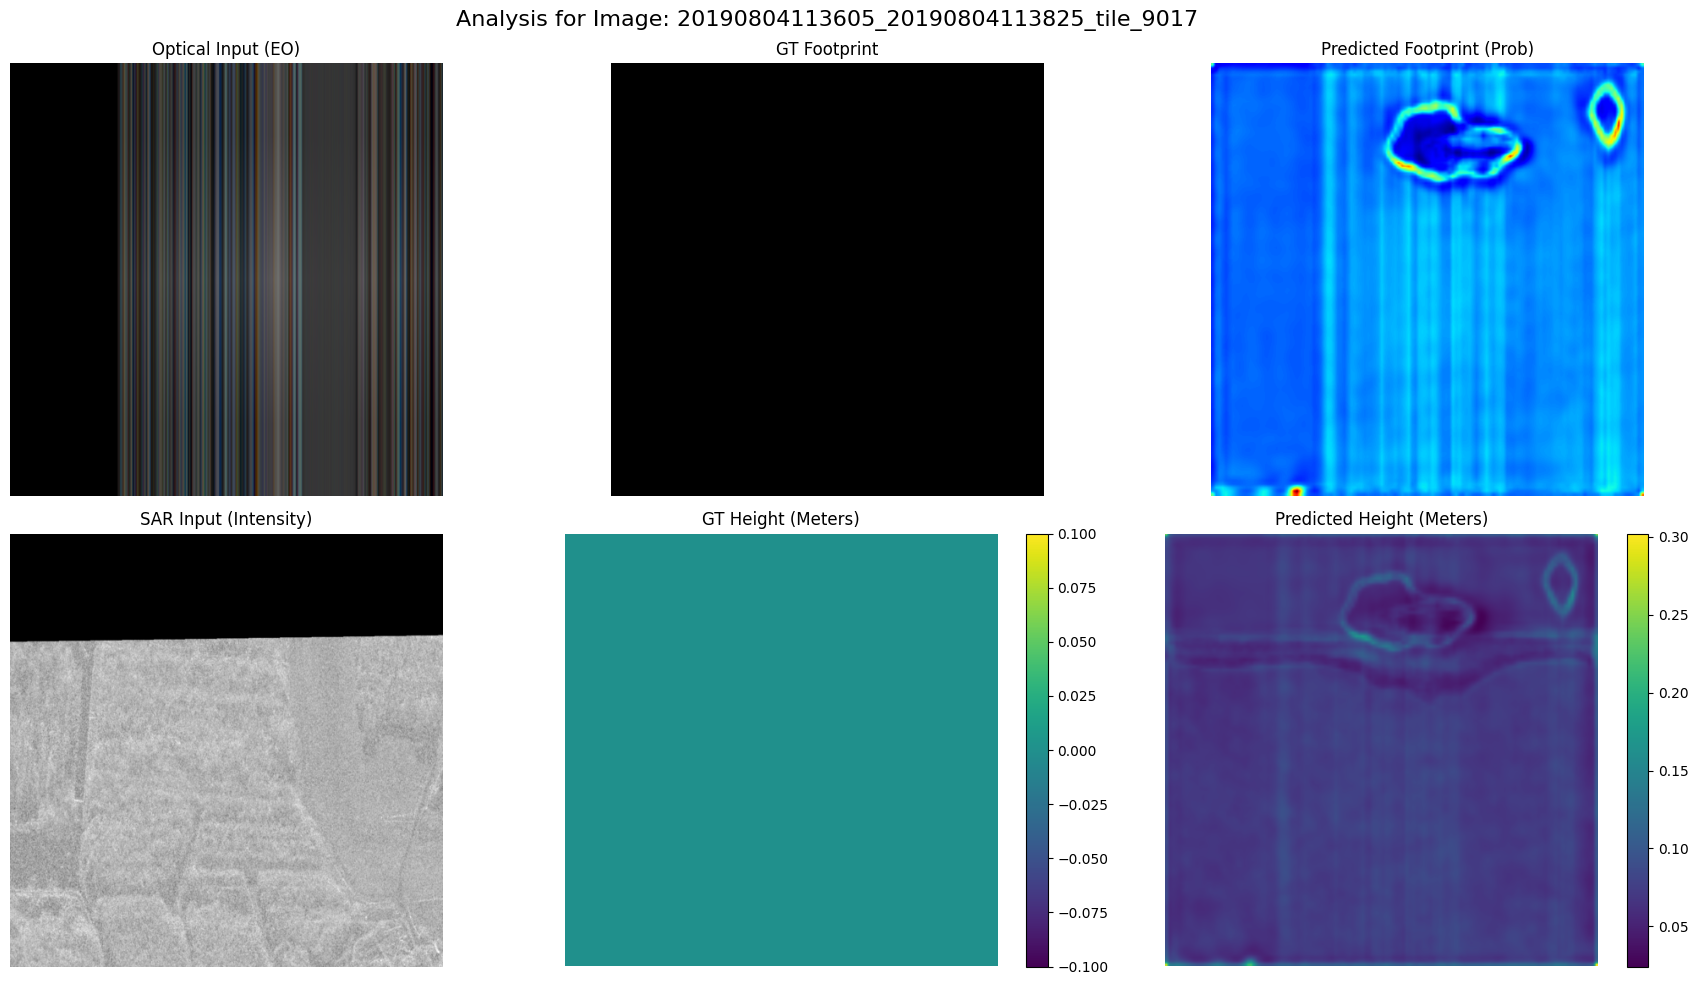

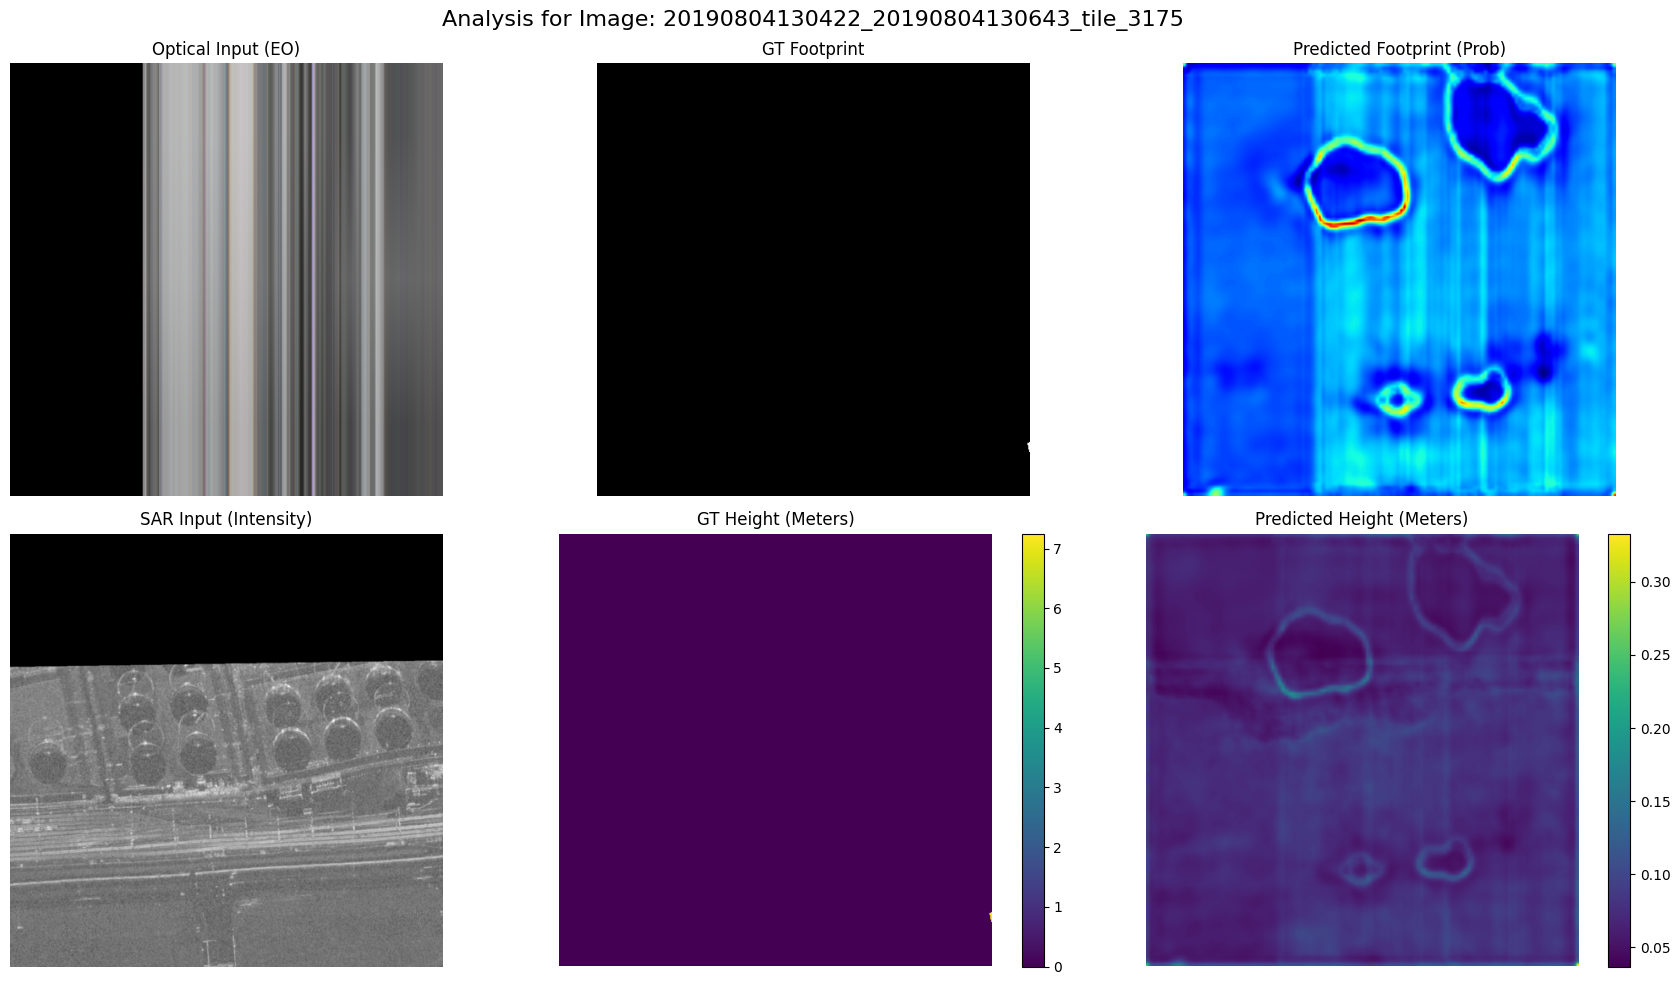

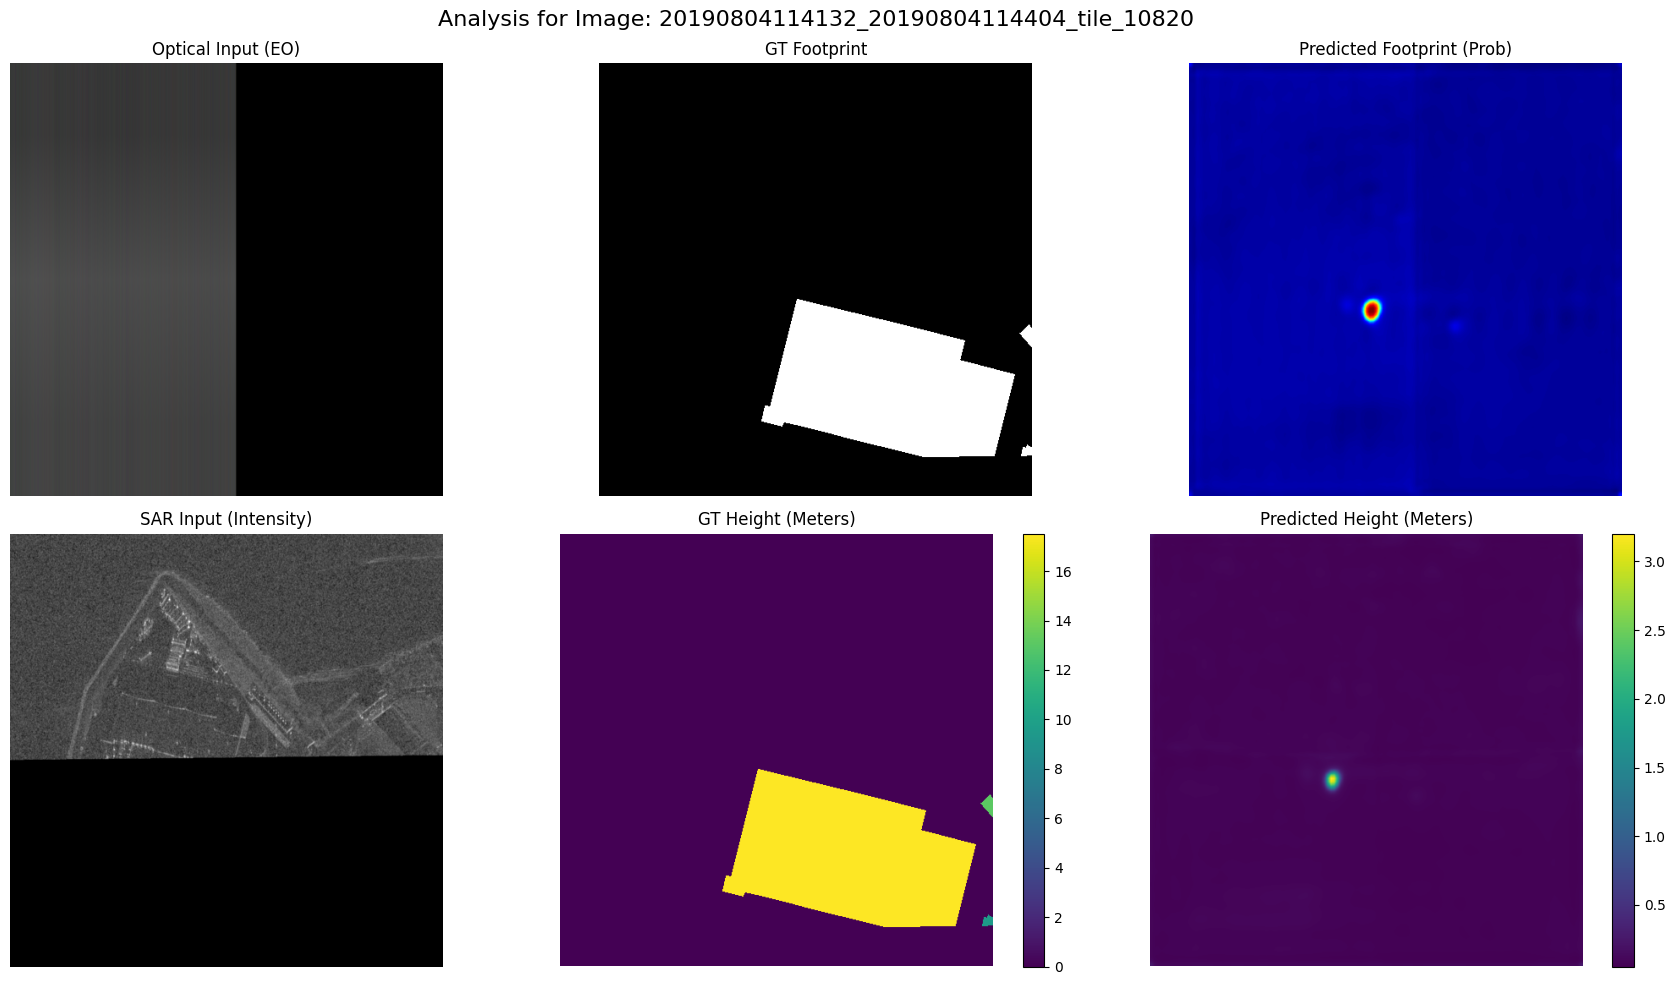

In [14]:
# Cell 10: Visualization of Predictions vs Ground Truth
import matplotlib.pyplot as plt

def visualize_prediction(model_path, dataset, max_h=100.0, num_samples=3):
    model = FusionHeightNet().to(device)
    model.load_state_dict(torch.load(model_path))
    model.eval()
    
    indices = np.random.choice(len(dataset), num_samples, replace=False)
    
    with torch.no_grad():
        for idx in indices:
            opt, sar, gt_foot, gt_height, img_id = dataset[idx]
            
            # Prepare inputs for model
            opt_in = opt.unsqueeze(0).to(device)
            sar_in = sar.unsqueeze(0).to(device)
            
            # Get model output
            pred_foot, pred_height = model(opt_in, sar_in)
            
            # Process Footprint: Get probability of building class
            pred_foot_prob = F.softmax(pred_foot, dim=1)[0, 1, :, :].cpu().numpy()
            
            # Process Height: Reverse Log-Normalization
            pred_norm = pred_height[0, 0, :, :].cpu().numpy()
            pred_h_meters = np.expm1(pred_norm * np.log1p(max_h))
            
            # Prepare GT for plotting
            gt_foot_np = gt_foot.cpu().numpy()
            gt_h_meters = gt_height[0].cpu().numpy()
            
            # Plotting
            fig, axes = plt.subplots(2, 3, figsize=(18, 10))
            fig.suptitle(f"Analysis for Image: {img_id}", fontsize=16)
            
            # Row 1: Inputs and Footprints
            axes[0, 0].imshow(opt.permute(1, 2, 0).cpu().numpy())
            axes[0, 0].set_title("Optical Input (EO)")
            
            axes[0, 1].imshow(gt_foot_np, cmap='gray')
            axes[0, 1].set_title("GT Footprint")
            
            axes[0, 2].imshow(pred_foot_prob, cmap='jet')
            axes[0, 2].set_title("Predicted Footprint (Prob)")
            
            # Row 2: SAR and Heights
            # SAR visualization (using first channel)
            axes[1, 0].imshow(sar[0].cpu().numpy(), cmap='gray')
            axes[1, 0].set_title("SAR Input (Intensity)")
            
            im_gt_h = axes[1, 1].imshow(gt_h_meters, cmap='viridis')
            axes[1, 1].set_title("GT Height (Meters)")
            fig.colorbar(im_gt_h, ax=axes[1, 1])
            
            im_pred_h = axes[1, 2].imshow(pred_h_meters, cmap='viridis')
            axes[1, 2].set_title("Predicted Height (Meters)")
            fig.colorbar(im_pred_h, ax=axes[1, 2])
            
            for ax in axes.flatten():
                ax.axis('off')
                
            plt.tight_layout()
            plt.show()

# Run visualization on the best model
if __name__ == '__main__':
    # --- FIX: Changed test_dataset to val_dataset ---
    visualize_prediction('fusion_height_net_best.pth', val_dataset, max_h=MAX_HEIGHT)